In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
# import os
# import sys
# import architecture
import FCYeast2_simulator
import torch
device='cpu'
l10=np.log(10)

In [2]:
g3 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_116224datapoints.csv')[-100000:,:]
map_index = np.argmax(g3[:,-1])
best_param = torch.tensor(g3[map_index]).float().to(device)
best_param


tensor([ 1.3358e+01, -3.4495e-01,  2.5792e+00, -2.1809e+00, -2.2817e+00,
         1.5725e+00, -3.2898e+00, -3.2781e+05])

In [3]:
g3.shape

(100000, 8)

In [4]:
FCYeast2_simulator.adjust_device(device)
target = FCYeast2_simulator.FCYeast_simulator.target()

def grid_plot(x,param,model,log10 = False):
    xp = torch.linspace(x.min(),x.max(),101).to(device)
    print(xp.type(),param.type(),torch.ones((101,4),device=device).type())
    lp = model.log_prob(xp.reshape(-1,1),torch.ones((101,4),device=device)*param)
    p = torch.exp(lp-lp.max())
    p *= 1/(p.sum()*(xp[1]-xp[0]))
    if log10:
        return xp.cpu()/l10,p.cpu()*l10
    return xp.cpu(),p.cpu()



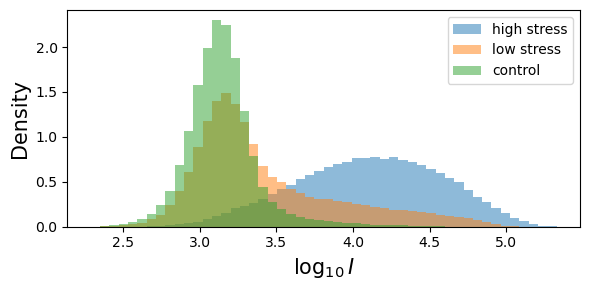

In [5]:
import os
import sys

c_directory = os.getcwd()
dils_str = ['12','23','33']
dils = [.12,.23,.33]
models=[]

dfs = [pd.read_csv(os.path.dirname(c_directory) +'/clean_data/complete_d={}.csv'.format(d)) for d in dils]
x = [torch.tensor(df['FL1-A'].to_numpy().astype(np.float32)).reshape(-1,1).to(device) for df in dfs]
x = [torch.log(xi)/l10 for xi in x]

plt.figure(figsize=(6, 3)) 
h = np.histogram((np.concatenate([xi.numpy() for xi in x])).reshape(-1),bins=50)
lab = ['high stress','low stress','control']
[plt.hist(xi.reshape(-1).numpy(),bins=h[1],alpha=.5,density=True,label=label) for (xi,label) in zip(x,lab)]
plt.xlabel(r'$\log_{10} I$',fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.legend()
plt.tight_layout()
plt.savefig('data_raw.png',dpi=500)

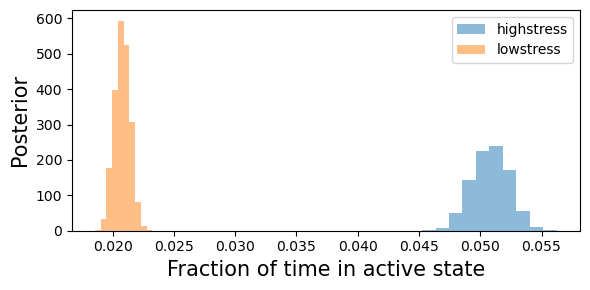

In [6]:
plt.figure(figsize=(6, 3)) 

lact = np.exp(g3[-100000:,1])
lina = np.exp(g3[-100000:,2])
frac = lact/(lact+lina)
plt.hist(frac,label = 'highstress',alpha=.5,density=True)

lact = np.exp(g3[-100000:,4])
lina = np.exp(g3[-100000:,5])
frac = lact/(lact+lina)
plt.hist(frac,label = 'lowstress',alpha=.5,density=True)


plt.ylabel('Posterior',fontsize=15)
plt.legend()
plt.xlabel('Fraction of time in active state',fontsize=15)
plt.tight_layout()
plt.savefig('frac',dpi=600)

In [7]:
mos = [['X' ,'X' ,'lact1','lina1','sig1'],
       ['bh','bh','lact1','lina1','sig1'],
       ['bh','bh','lact2','lina2','sig2'],
       ['X' ,'X' ,'lact2','lina2','sig2']]

moA = [['bh1','lact1','lina1','sig1'],
       ['bh2','lact2','lina2','sig2']]

In [8]:
dils = [.12,.23]

def separate(x):
    return np.array(((x[0],x[1],x[2],x[3]),
                     (x[0],x[4],x[5],x[6])))

to_hours = -np.array(((0,-1,-1,0),
                     (0,-1,-1,0)))*np.log(dils).reshape(-1,1)

def transform_to_hour(x): #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all in hours
    return separate(x) + to_hours


to_arbitrary = -np.array(((1, 0, 0, 0),
                          (1, 0, 0, 0)))*np.log(dils).reshape(-1,1)

def transform_to_arbitrary(x):  #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all to arbitrary
    return separate(x) + to_arbitrary

def separate_sampled_par(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_hour(sp)
        #sp_sep=separate(sp)
        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

def separate_sampled_arb(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_arbitrary(sp)

        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

In [9]:
torch.exp(FCYeast2_simulator.transform_to_arbitrary((best_param)))

tensor([[5.2717e+06, 7.0825e-01, 1.3187e+01, 1.1294e-01],
        [2.7505e+06, 1.0211e-01, 4.8184e+00, 3.7262e-02]])

In [10]:
np.exp(transform_to_hour((best_param)))

array([[6.32605396e+05, 8.49903304e-02, 1.58239549e+00, 1.12939209e-01],
       [6.32605396e+05, 2.34862956e-02, 1.10824245e+00, 3.72615079e-02]])

In [21]:
tranform_fun = {'ln':lambda x:x,
                'log10': lambda x:x/np.log(10),
                'real': np.exp}
tranform_pre = {'ln': r'$\ln$',
                'log10': r'$\log_{10}$',
                'real': ''}

def make_fig(sampled_par,lp,transform = 'ln',time_scale='real'):
    if time_scale == 'real':
        fig,ax = plt.subplot_mosaic(mos,figsize=(16,6),empty_sentinel='X')
        s1,s2 = separate_sampled_par(sampled_par)
    elif time_scale == 'arbitrary':
        fig,ax = plt.subplot_mosaic(moA,figsize=(16,8))
        s1,s2 = separate_sampled_arb(sampled_par)
    
    

    gr = ['bh','lact1','lina1','sig1']
    lab = [r'$\beta$',r'$\lambda_{act}$',r'$\lambda_{ina}$',r'$\sigma$']

    fun = tranform_fun[transform]
    s1,s2 = fun(s1),fun(s2)
    prelabel = tranform_pre[transform]
    lab = [prelabel + ' ' + l + r' (${h^{-1}}$)' for l in lab[:3]] +[prelabel + ' ' + lab[3]]

    gr = ['lact1','lina1','sig1']
    [ax[gr[i]].hist(s1[:,i+1],bins=35,density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=22) for i in range(3)]
    ax[gr[0]].set_ylabel(r'$\bar{{T}} ={:.2f} h $ (high stress)'.format((1/dils[0])),fontsize=13)

    gr = ['lact2','lina2','sig2']
    [ax[gr[i]].hist(s2[:,i+1],bins=35,density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=22) for i in range(3)]
    ax[gr[0]].set_ylabel(r'$\bar{{T}} ={:.2f} h$ (low stress)'.format((1/dils[1])),fontsize=13)

    if time_scale == 'real':
        ax['bh'].hist(s1[:,0],bins=35,density=True)
        ax['bh'].set_xlabel(lab[0],fontsize=18)

        # ax['lp'].plot(lp)
        # ax['lp'].axvline(len(lp)-len(sampled_par),color='r')
        # ax['lp'].set_ylim(lp.max()-100,lp.max())
        # ax['lp'].set_ylabel(r'$\log$ posterior')

    elif time_scale == 'arbitrary':
        for (bhi,si) in zip([m[0] for m in moA],(s1,s2)):
            ax[bhi].hist(si[:,0],density=True)
            ax[bhi].set_xlabel(lab[0],fontsize=12)
       

    
    plt.tight_layout()

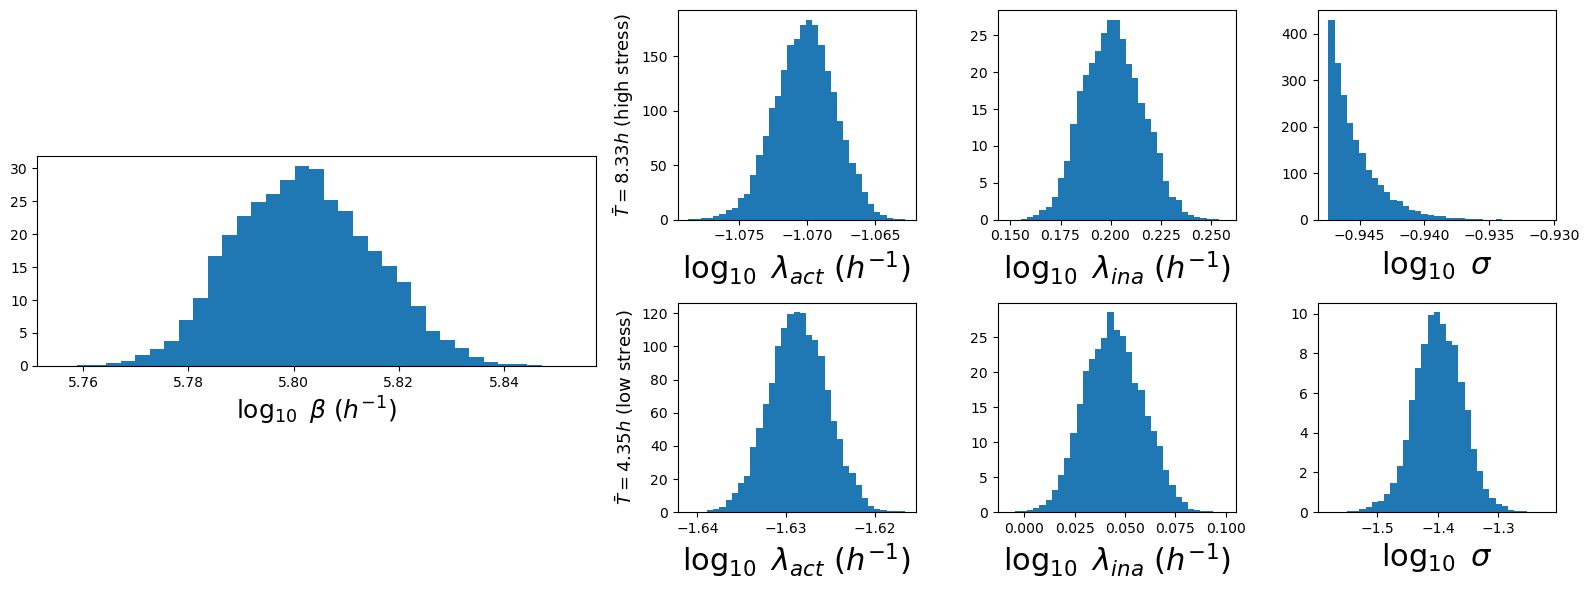

In [22]:
make_fig(g3[-100000:,:-1],g3[-100000:,-1],transform='log10')
plt.savefig('result.png',dpi=500)

In [13]:
s1,s2 = separate_sampled_par(g3)
cols = ['log_10'+ s for s in ['Production rate', 'Activation rate', 'Inactivation rate', 'Cell division variance']]

df1 = pd.DataFrame((s1/np.log(10))[-100000:,:],columns=cols)
df1.to_csv('FCYeast2_MCMC/results_highstress.csv')

df2 = pd.DataFrame((s2/np.log(10))[-100000:,:],columns=cols)
df2.to_csv('FCYeast2_MCMC/results_lowstress.csv')

In [14]:
1/np.array(dils)

array([8.33333333, 4.34782609])

In [15]:

def forward_run(beta,lact,lina,sig,div_t,mother_only=True,dt=.1):
    #print('fraction of time in active state',lact/(lina+lact))
    nu = 1/((sig)**2)
    div_times = torch.distributions.Gamma(nu,nu).sample((100,)).numpy()
    div_times = div_times[np.cumsum((div_t*div_times))<400]
    sizes = target.rho.sample(div_times.shape).numpy()
    if mother_only:
        sizes = np.maximum(sizes,1-sizes)

    traj_times=[]
    traj_protein=[]
    traj_state=[]

    s= int(np.random.rand()<lina/(lact+lina))

    t=0
    P=0
    for T,newsize in zip(div_times,sizes):
        tin = 0
        while tin<T:
            if s == 1:
                switch_time = np.random.exponential(1/lina)
                fin_time = min(T,tin+switch_time)
                while tin<fin_time:
                    tin+=dt
                    P+=np.random.poisson(beta*dt)

                    traj_protein.append(P*1)
                    traj_times.append(t+tin*1)
                    traj_state.append(s*1)
                if fin_time!=T:
                    s=0
            else: # s == 0
                switch_time = np.random.exponential(1/lact)
                if switch_time<T:
                    tin+=switch_time
                    s=1
                else:
                    tin = T


        P = np.random.binomial(P,newsize)
        
        t+=T
        traj_protein.append(P*1)
        traj_times.append(t*1)
        traj_state.append(s*1)
        



    return div_t*np.array(traj_times),np.array(traj_protein)


In [16]:
map_arbitrary = [np.exp(arr[map_index]) for arr in separate_sampled_arb(g3)]
map_arbitrary

[array([5.27171163e+06, 7.08252754e-01, 1.31866291e+01, 1.12939209e-01]),
 array([2.75045824e+06, 1.02114329e-01, 4.81844544e+00, 3.72615079e-02])]

Text(0, 0.5, 'Protein number')

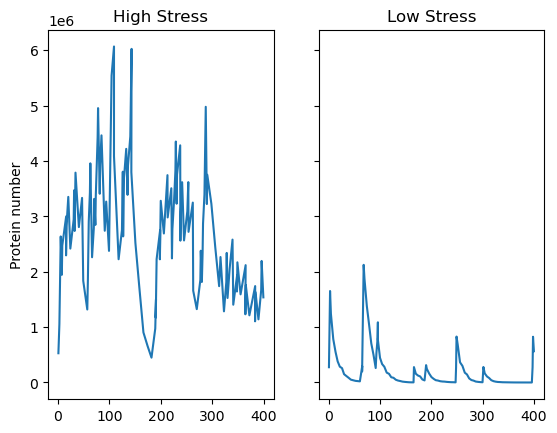

In [17]:
fig,ax = plt.subplots(1,2,sharey=True)
ax[0].plot(*forward_run(*map_arbitrary[0],1/dils[0]))
ax[0].set_title('High Stress')
ax[1].plot(*forward_run(*map_arbitrary[1],1/dils[1]))
ax[1].set_title('Low Stress')
ax[0].set_ylabel('Protein number')

In [18]:
#run 100 simulations and plot steady_state 
Nsamples=10000
final_high = [ forward_run(*map_arbitrary[0],1/dils[0])[1][-1] for i in range(Nsamples)]
final_low  = [ forward_run(*map_arbitrary[1],1/dils[1])[1][-1] for i in range(Nsamples)]

Text(0.5, 0, 'Protein number')

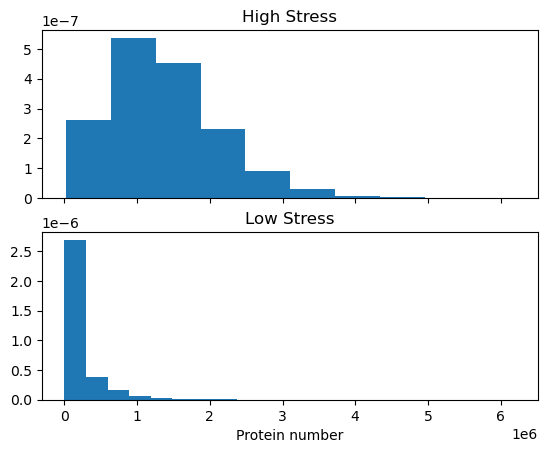

In [19]:
fig,ax = plt.subplots(2,1,sharex=True)
ax[0].hist(final_high,density=True)
ax[0].set_title('High Stress')
ax[1].hist(final_low,density=True)
ax[1].set_title('Low Stress')
ax[-1].set_xlabel('Protein number')

/tmp/ipykernel_228006/4086259457.py:5: RuntimeWarning: divide by zero encountered in log10
  ax[1].hist(np.log10(final_low),bins=h[1],density=True)


Text(0.5, 0, '$\\log_{10}$ Protein number')

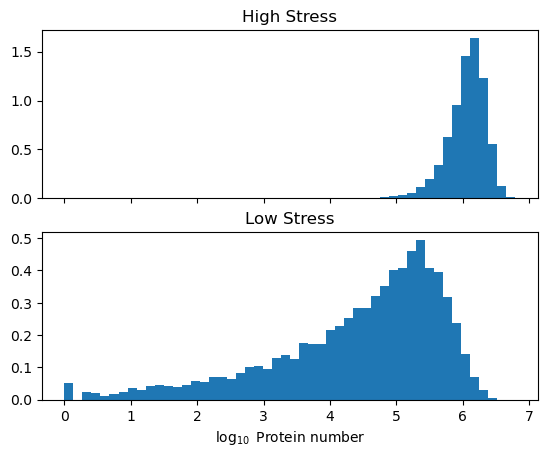

In [20]:
fig,ax = plt.subplots(2,1,sharex=True)
h = np.histogram(np.log10(np.concatenate((final_high,final_low)).clip(1)),bins=50)
ax[0].hist(np.log10(final_high),bins=h[1],density=True)
ax[0].set_title('High Stress')
ax[1].hist(np.log10(final_low),bins=h[1],density=True)
ax[1].set_title('Low Stress')
ax[-1].set_xlabel(r'$\log_{10}$ Protein number')